# Dédalo + SRAB — Simulação de Deploy PocketQube (LASC 2026)


Pipeline completo de simulação do foguete **Dédalo** (Serra Rocketry) carregando o **PocketQube Helike #213**,
com deploy no apogeu e descida do payload usando o sistema de autorrotação **SRAB (Samara Recovery Wing)**.


## Visão Geral


| Fase | Veículo | Método | Descrição |
|------|---------|--------|-----------|
| **Stage 1** | Dédalo completo (com payload) | RocketPy `Flight` | Subida até o apogeu |
| **Stage 2** | Dédalo vazio (sem payload) | RocketPy `Flight` + `initial_solution` | Descida com paraquedas |
| **Stage 3** | PocketQube (payload) | `SRABRecovery.simulate_from_flight()` | Descida autorrotativa com asas SRAB |


| Parâmetro | Valor |
|-----------|-------|
| **Foguete** | Dédalo (Serra Rocketry/UERJ), 106 mm Ø, 5.35 kg |
| **Motor** | Sólido caseiro (926 N pico, 2.82 s queima) |
| **Payload** | PocketQube 1P (~200 g) |
| **Paraquedas** | CdS=10.0, trigger por apogeu |
| **SRAB** | Asa3.DXF, 2 asas, β=5° |
| **Lançamento** | Tatuí-SP (-21.943, -48.954), 478 m ASL |


**Referências:**

- [RocketPy Deployable Payload](https://docs.rocketpy.org/en/latest/user/deployable.html)

- Modelo SRAB: `samara_pq_simulation.py` (árvore `src/`)

- Missão Helike #213 — LASC 2026



## Setup


Importa as dependências e configura os caminhos absolutos do projeto.

O módulo SRAB está em `src/` e as geometrias em `geometry/`.



In [ ]:
import sys, io, os
from pathlib import Path
from datetime import datetime, timedelta
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from rocketpy import Environment, SolidMotor, Rocket, Flight

# ── Caminhos absolutos ─────────────────────────────────────────
NOTEBOOK_DIR = Path(os.path.abspath("")).resolve()
WING_SRC = NOTEBOOK_DIR.parent / "src"
DXF_DIR = WING_SRC.parent / "geometry"

sys.path.insert(0, str(WING_SRC))
from rocketpy_samara.srab_recovery import SRABRecovery
from rocketpy_samara.plotting import plot_lrr_dashboard, plot_trajectory_map

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Wing src:     {WING_SRC}")
print(f"DXF dir:      {DXF_DIR}")
print("RocketPy + SRAB modules carregados OK")


Notebook dir: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks
Wing src:     /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/src
DXF dir:      /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/geometry
RocketPy + SRAB modules carregados OK


## 1. Ambiente Atmosférico


Configura o ambiente de lançamento em **Tatuí-SP** (base Serra Rocketry).

Usa atmosfera padrão ISA (sem vento) para a simulação nominal.



In [ ]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)
env.set_date(datetime.datetime.now())
env.set_atmospheric_model(type="Forecast", file="GFS")
print(f"Densidade ao nivel do solo: {env.density(0):.3f} kg/m³")
print("Lançamento setado para: ", env.datetime_date)


Densidade ao nivel do solo: 1.157 kg/m³
Lançamento setado para:  2026-07-27 22:06:27.732321+00:00


## 2. Motor do Foguete


Motor sólido caseiro (Serra Rocketry), curva de empuxo medida em bancada.



Motor data: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/motor.csv
Motor config: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/dedalo_motor.json
Motor criado: 95 pontos de empuxo, queima 2.82 s, pico 926 N



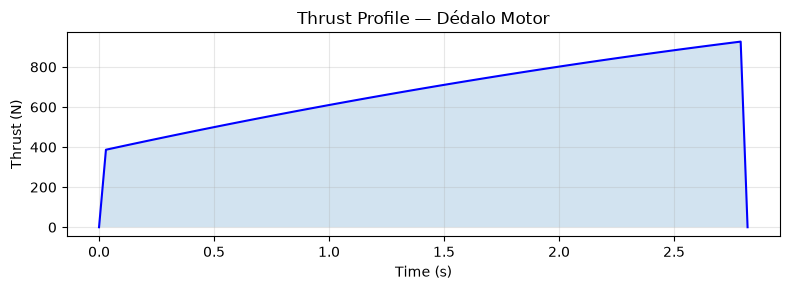

In [ ]:
# ── Carrega dados do motor ──
MOTOR_CSV = NOTEBOOK_DIR / "motor.csv"
MOTOR_JSON = NOTEBOOK_DIR / "dedalo_motor.json"
print(f"Motor data: {MOTOR_CSV}")
print(f"Motor config: {MOTOR_JSON}")

motor_data = pd.read_csv(MOTOR_CSV)
with open(MOTOR_JSON) as f:
    motor_config = json.load(f)

Dedalo_motor = SolidMotor(
    thrust_source=motor_data,
    dry_mass=motor_config["dry_mass"],
    dry_inertia=motor_config["dry_inertia"],
    nozzle_radius=motor_config["nozzle_radius"],
    grain_number=motor_config["grain_number"],
    grain_density=motor_config["grain_density"],
    grain_outer_radius=motor_config["grain_outer_radius"],
    grain_initial_inner_radius=motor_config["grain_initial_inner_radius"],
    grain_initial_height=motor_config["grain_initial_height"],
    grain_separation=motor_config["grain_separation"],
    grains_center_of_mass_position=motor_config["grains_center_of_mass_position"],
    center_of_dry_mass_position=motor_config["center_of_dry_mass_position"],
    nozzle_position=motor_config["nozzle_position"],
    burn_time=motor_data["Time(s)"].iloc[-1],
    throat_radius=motor_config["throat_radius"],
    coordinate_system_orientation=motor_config["coordinate_system_orientation"],
)

print(f"Motor criado: {len(motor_data)} pontos de empuxo, "
      f"queima {motor_data["Time(s)"].iloc[-1]:.2f} s, "
      f"pico {motor_data["Thrust(N)"].max():.0f} N\n")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(motor_data["Time(s)"], motor_data["Thrust(N)"], "b-")
ax.fill_between(motor_data["Time(s)"], motor_data["Thrust(N)"], alpha=0.2)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Thrust (N)")
ax.set_title("Thrust Profile — Dédalo Motor")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Foguete com Payload — Subida (Stage 1)


Modelagem do Dédalo completo (estrutura + motor + payload PocketQube).

**Payload:** PocketQube 1P (~110 g), montado no compartimento de carga útil.


> O motor é montado com o bocal voltado para baixo (*nozzle_to_combustion_chamber*).

> O foguete usa sistema de coordenadas nariz-para-cauda (*nose_to_tail*).



In [ ]:
# ── Carrega dados do foguete ──
ROCKET_JSON = NOTEBOOK_DIR / "dedalo_data.json"
print(f"Rocket config: {ROCKET_JSON}")
with open(ROCKET_JSON) as f:
    rocket_data = json.load(f)

# ── Curvas de arrasto (Cd vs Mach) ──
POWER_OFF_DRAG = NOTEBOOK_DIR / "power_off_drag.csv"
POWER_ON_DRAG  = NOTEBOOK_DIR / "power_on_drag.csv"

print(f"power_off_drag: {POWER_OFF_DRAG}")
print(f"power_on_drag:  {POWER_ON_DRAG}")

# Massa: foguete sem motor (do JSON) + payload PocketQube (0.200 kg)
PAYLOAD_MASS = 0.200  # kg (PocketQube 1P)
ROCKET_MASS_NO_MOTOR = rocket_data["mass"]
TOTAL_MASS = ROCKET_MASS_NO_MOTOR + PAYLOAD_MASS

Dedalo_full = Rocket(
    radius=rocket_data["radius"],
    mass=TOTAL_MASS,
    inertia=rocket_data["inertia"],
    power_off_drag=str(POWER_OFF_DRAG),
    power_on_drag=str(POWER_ON_DRAG),
    center_of_mass_without_motor=rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation=rocket_data["coordinate_system_orientation"],
)

# ── Motor ──
Dedalo_full.add_motor(Dedalo_motor, position=1.65)

# ── Ponta ──
Dedalo_full.add_nose(
    length=rocket_data["nose_length"],
    kind=rocket_data["nose_type"],
    position=rocket_data["nose_position"],
)

# ── Aletas ──
Dedalo_full.add_trapezoidal_fins(
    n=rocket_data["n_aletas"],
    root_chord=rocket_data["root_chord"],
    tip_chord=rocket_data["tip_chord"],
    span=rocket_data["span"],
    position=rocket_data["position"],
    cant_angle=rocket_data["cant_angle"],
)

print(f"\nFoguete Dédalo (com payload) montado:")
print(f"  Massa total:   {Dedalo_full.mass:.3f} kg ({TOTAL_MASS:.3f} kg config)")
print(f"  Massa motor:   {Dedalo_motor.dry_mass:.3f} kg")
print(f"  Payload:       {PAYLOAD_MASS:.3f} kg (PocketQube 1P)")
print(f"  Diametro:      {Dedalo_full.radius*2000:.0f} mm")


Rocket config: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/dedalo_data.json
power_off_drag: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/power_off_drag.csv
power_on_drag:  /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/notebooks/power_on_drag.csv

Foguete Dédalo (com payload) montado:
  Massa total:   5.100 kg (5.100 kg config)
  Massa motor:   1.860 kg
  Payload:       0.200 kg (PocketQube 1P)
  Diametro:      106 mm


### 3.1 Simulação da Subida (Stage 1)


Simulação com `terminate_on_apogee=True` para parar automaticamente no ponto

mais alto da trajetória. O paraquedas não é necessário nesta fase — o deploy

ocorre no Stage 2 (foguete vazio) e o SRAB no Stage 3 (payload).



In [ ]:
flight_with_payload = Flight(
    rocket=Dedalo_full,
    environment=env,
    rail_length=4.0,
    inclination=85,
    heading=0,
    terminate_on_apogee=True,
)

print(f"Stage 1 — Subida Dédalo (com payload):")
print(f"  Apogeu:         {flight_with_payload.apogee - env.elevation:.0f} m AGL, "
      f"{flight_with_payload.apogee:.0f} m ASL")
print(f"  Tempo apogeu:   {flight_with_payload.apogee_time:.2f} s")
print(f"  Vel. max:       {flight_with_payload.max_speed:.1f} m/s "
      f"({flight_with_payload.max_mach_number:.2f} Mach)")
print(f"  Acel. max:      {flight_with_payload.max_acceleration:.1f} m/s² "
      f"({flight_with_payload.max_acceleration/9.80665:.1f} G)")
print(f"  Dist. trilho:   {flight_with_payload.out_of_rail_time:.2f} s, "
      f"{flight_with_payload.out_of_rail_velocity:.1f} m/s")
print(f"  Impacto (sem paraquedas): x={flight_with_payload.x_impact:.1f}, "
      f"y={flight_with_payload.y_impact:.1f} m")


Stage 1 — Subida Dédalo (com payload):
  Apogeu:         1520 m AGL, 1996 m ASL
  Tempo apogeu:   17.83 s
  Vel. max:       205.3 m/s (0.59 Mach)
  Acel. max:      106.7 m/s² (10.9 G)
  Dist. trilho:   0.47 s, 18.9 m/s
  Impacto (sem paraquedas): x=0.0, y=0.0 m


## 4. Foguete sem Payload — Descida com Paraquedas (Stage 2)


Após o deploy do payload no apogeu, o foguete (agora mais leve) retorna

com um paraquedas tradicional. A simulação continua a partir das condições finais

do Stage 1 (apogeu).



In [ ]:
# ── Foguete sem payload (descida) ──
Dedalo_empty = Rocket(
    radius=rocket_data["radius"],
    mass=ROCKET_MASS_NO_MOTOR,
    inertia=rocket_data["inertia"],
    power_off_drag=str(POWER_OFF_DRAG),
    power_on_drag=str(POWER_ON_DRAG),
    center_of_mass_without_motor=rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation=rocket_data["coordinate_system_orientation"],
)
Dedalo_empty.add_motor(Dedalo_motor, position=1.65)
Dedalo_empty.add_nose(
    length=rocket_data["nose_length"],
    kind=rocket_data["nose_type"],
    position=rocket_data["nose_position"],
)
Dedalo_empty.add_trapezoidal_fins(
    n=rocket_data["n_aletas"],
    root_chord=rocket_data["root_chord"],
    tip_chord=rocket_data["tip_chord"],
    span=rocket_data["span"],
    position=rocket_data["position"],
    cant_angle=rocket_data["cant_angle"],
)

# ── Paraquedas (trigger no apogeu via vz < 0) ──
def apogee_acc_trigger(_pressure, _height, state_vector, u_dot):
    vz = state_vector[5]
    az = u_dot[5]
    return abs(vz) < 1.0 and az < -0.1

Dedalo_empty.add_parachute(
    name="main",
    cd_s=1.5,
    trigger=apogee_acc_trigger, 
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)
print(f"Foguete vazio ({ROCKET_MASS_NO_MOTOR:.3f} kg) + paraquedas CdS=10.0")


Foguete vazio (4.900 kg) + paraquedas CdS=10.0


In [ ]:
flight_without_payload = Flight(
    rocket=Dedalo_empty,
    environment=env,
    rail_length=4.0,
    inclination=85,
    heading=0,
    initial_solution=flight_with_payload,
)

print(f"Stage 2 — Descida Dédalo vazio (com paraquedas):")
print(f"  Apogeu:         {flight_without_payload.apogee - env.elevation:.0f} m AGL")
print(f"  Vel. max:       {flight_without_payload.max_speed:.1f} m/s "
      f"({flight_without_payload.max_mach_number:.2f} Mach)")
print(f"  Impacto:        x={flight_without_payload.x_impact:.1f}, "
      f"y={flight_without_payload.y_impact:.1f} m")
print(f"  Tempo total:    {flight_without_payload.t_final:.1f} s")


Stage 2 — Descida Dédalo vazio (com paraquedas):
  Apogeu:         1520 m AGL
  Vel. max:       17.8 m/s (0.05 Mach)
  Impacto:        x=-139.7, y=43.2 m
  Tempo total:    183.5 s


## 5. Payload PocketQube — Descida SRAB (Stage 3)


O payload (PocketQube) não usa paraquedas convencionais. Em vez disso,

utiliza asas **SRAB (Samara Recovery Wing)** — asas bio-inspiradas em sementes

de samara que geram autorrotação estabilizada durante a queda, reduzindo a

velocidade de impacto a níveis seguros (< 13.3 m/s com fator de segurança 1.5).


### Parâmetros da Asa


| Parâmetro | Valor |
|-----------|-------|
| **Geometria** | Asa3.DXF (2 asas simétricas) |
| **Ângulo de conicidade (β)** | 5° |
| **Massa do payload** | 200 g |
| **Velocidade max. admissível** | 20 m/s (LASC) → 13.3 m/s c/ FS 1.5 |



In [ ]:
# ── Carrega geometria da asa ──
from samara_pq_simulation import PocketQubeSamaraWing

DXF_PATH = DXF_DIR / "Asa3.DXF"
print(f"DXF: {DXF_PATH}")

wing = PocketQubeSamaraWing(
    dxf_path=str(DXF_PATH),
    n_wings=2,
    mass=0.200,          # 200 g — PocketQube 1P
    f_factor=0.3,
    cd0=1.0,
    rho=1.225,
    beta_deg=5.0,
)

print(f"Asa SRAB configurada:")
print(f"  Asas:          {wing.n_wings}")
print(f"  Massa:         {wing.mass * 1000:.0f} g")
print(f"  Raio (DXF):    {wing.radius * 100:.2f} cm")
print(f"  r0 → rf:       {wing.base_r0 * 1e3:.1f} → {wing.base_rf * 1e3:.1f} mm")
print(f"  beta:          {wing.beta_mount:.1f} rad")


DXF: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/geometry/Asa3.DXF
Asa SRAB configurada:
  Asas:          2
  Massa:         200 g
  Raio (DXF):    6.11 cm
  r0 → rf:       0.0 → 61.1 mm
  beta:          0.1 rad


In [ ]:
# ── Wing Geometry — Orthogonal Views ──
from samara_pq_simulation import plot_wing_geometry_views
from IPython.display import Image, display

# Plot and save geometry views (temp directory)
TMP_DIR = NOTEBOOK_DIR.parent / "temp"
TMP_DIR.mkdir(parents=True, exist_ok=True)

plot_wing_geometry_views(
    wing,
    theta_eq_deg=15.0,  # nominal static estimate
    output_dir=str(TMP_DIR),
)

# Display the saved image inline
img_path = TMP_DIR / "samara_pq_geometry_views.png"
if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print(f"[WARN] Geometry plot not found: {img_path}")


### 5.1 Otimização do Raio


O raio aerodinâmico é otimizado para que a velocidade de impacto

não ultrapasse **Vf_max / FS = 13.3 m/s** (limite LASC com fator de segurança 1.5).



In [ ]:
# ── SRABRecovery com otimizacao interna ──
SAFETY_FACTOR = 1.5
VF_MAX = 20.0          # limite estrutural / LASC
VF_TARGET = VF_MAX / SAFETY_FACTOR  # ~13.3 m/s

srab = SRABRecovery(
    wing, env=env,
    dxf_path=str(DXF_PATH),
    n_wings=2,
    mass_kg=0.200,
    theta_deg=0.0,
    theta_dot_0=0.0,
    phi_dot_0=0.1,
    v0_0=0.0,
    beta_deg=5.0,
    cd0=1.0,
    f_factor=0.3,
    rho=1.225,
    t_max=300.0,
    max_step=0.2,
    optimize=True,
    target_vf=VF_TARGET,
    safety_factor=SAFETY_FACTOR,
)

# Simulacao standalone p/ verificar a otimizacao
print("Executando otimizacao de raio + simulacao SRAB...")
sol = srab.simulate(altitude_m=1000.0)

print(f"Raio otimizado:   {wing.radius * 100:.2f} cm")
print(f"v_impacto:        {sol.v_impact:.2f} m/s  (alvo: {VF_TARGET:.2f} m/s)")
print(f"t_descida:        {sol.t_impact:.1f} s")
print(f"theta_eq:         {sol.theta_eq:.1f} deg")
print(f"Spin impacto:     {sol.spin_impact_rpm:.0f} RPM")


Executando otimizacao de raio + simulacao SRAB...

[ENGINEERING] Solving required radius for target impact vf=
-13.33 m/s...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
[SUCCESS] Impact-velocity radius solved!
 -> Required aerodynamic radius: 7.97 cm
 -> Impact event detected: True
 -> Impact vertical velocity: -13.333 m/s
 -> Residual |vf_impact - tar

### 5.2 Descida SRAB a partir do Apogeu Real


Agora conectamos o SRAB ao apogeu do Stage 1, usando as condições reais

de altitude, velocidade e orientação do foguete no momento do deploy.



In [ ]:
# SRAB a partir do Flight Stage 1
sol_deploy = srab.simulate_from_flight(
    flight_with_payload,
    theta_deg=0.0,
    target_vf=VF_TARGET,
)

print(f"Descida SRAB a partir do apogeu real:")
print(f"  Altitude liberacao: {sol_deploy.altitude[0]:.1f} m AGL")
print(f"  v_z no apogeu:      {sol_deploy.v0[0]:.2f} m/s")
print(f"  Duracao descida:    {sol_deploy.t_impact:.1f} s")
print(f"  v_impacto:          {sol_deploy.v_impact:.2f} m/s")
print(f"  theta_eq:           {sol_deploy.theta_eq:.1f} deg")
print(f"  Spin impacto:       {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"  Posicao impacto:    x={sol_deploy.x_impact:.1f}, y={sol_deploy.y_impact:.1f} m")



[ENGINEERING] Solving required radius for target impact vf=
-13.33 m/s...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
-> Propagating ballistic trajectory (this may take a few seconds)...
[SUCCESS] Impact-velocity radius solved!
 -> Required aerodynamic radius: 7.97 cm
 -> Impact event detected: True
 -> Impact vertical velocity: -13.333 m/s
 -> Residual |vf_impact - target|: 0.000 m/s
  Raio otimizado: 7.97 cm
-> Propa

## 6. Comparação de Trajetórias


Visualização simultânea do Stage 1 (subida Dédalo) e Stage 2 (descida Dédalo vazio).



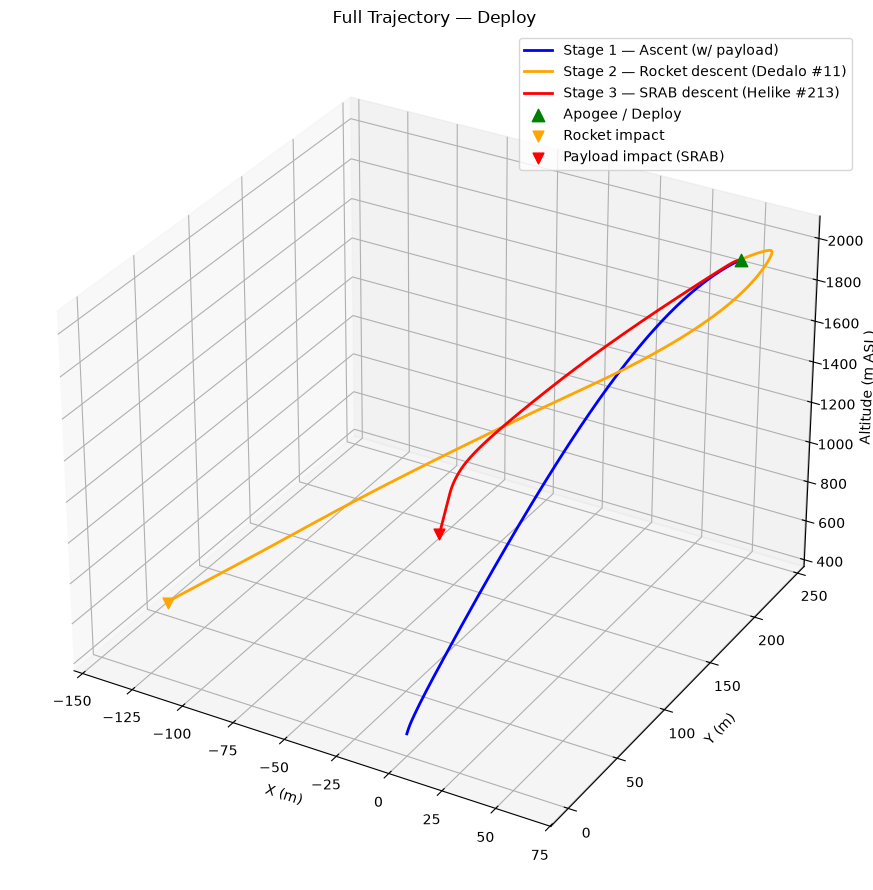

In [ ]:
from rocketpy.plots.compare import CompareFlights

comparison = CompareFlights([flight_with_payload, flight_without_payload])

# Trajetória 3D — Stage 1 + 2 + SRAB
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Stage 1 (ascent)
t_apo = flight_with_payload.apogee_time
t_asc = np.linspace(0, t_apo, 300)
x_asc = np.array([flight_with_payload.x(t) for t in t_asc])
y_asc = np.array([flight_with_payload.y(t) for t in t_asc])
z_asc = np.array([flight_with_payload.z(t) for t in t_asc])
ax.plot(x_asc, y_asc, z_asc, "b-", lw=2, label="Stage 1 — Ascent (w/ payload)")

# Stage 2 (descent with parachutes) — tempo relativo ao apogeu (t=0)
t_desc = np.linspace(0, flight_without_payload.t_final, 300)
x_desc = np.array([flight_without_payload.x(t) for t in t_desc])
y_desc = np.array([flight_without_payload.y(t) for t in t_desc])
z_desc = np.array([flight_without_payload.z(t) for t in t_desc])
ax.plot(x_desc, y_desc, z_desc, "orange", lw=2, label="Stage 2 — Rocket descent (Dedalo #11)")

# Stage 3 (SRAB descent) — altitude AGL, soma ELEV para ASL no plot
z_srab = sol_deploy.altitude + flight_with_payload.env.elevation
ax.plot(sol_deploy.x, sol_deploy.y, z_srab, "r-", lw=2, label="Stage 3 — SRAB descent (Helike #213)")

# Apogeu
ax.scatter(
    flight_with_payload.x(t_apo), flight_with_payload.y(t_apo),
    flight_with_payload.z(t_apo),
    c="g", s=80, marker="^", label="Apogee / Deploy", zorder=5
)

# Impactos
ax.scatter(
    flight_without_payload.x(flight_without_payload.t_final),
    flight_without_payload.y(flight_without_payload.t_final),
    flight_without_payload.z(flight_without_payload.t_final),
    c="orange", s=60, marker="v", label="Rocket impact", zorder=5
)
ax.scatter(
    sol_deploy.x_impact, sol_deploy.y_impact, flight_with_payload.env.elevation,
    c="r", s=60, marker="v", label="Payload impact (SRAB)", zorder=5
)

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Altitude (m ASL)")
ax.set_title("Full Trajectory — Deploy")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

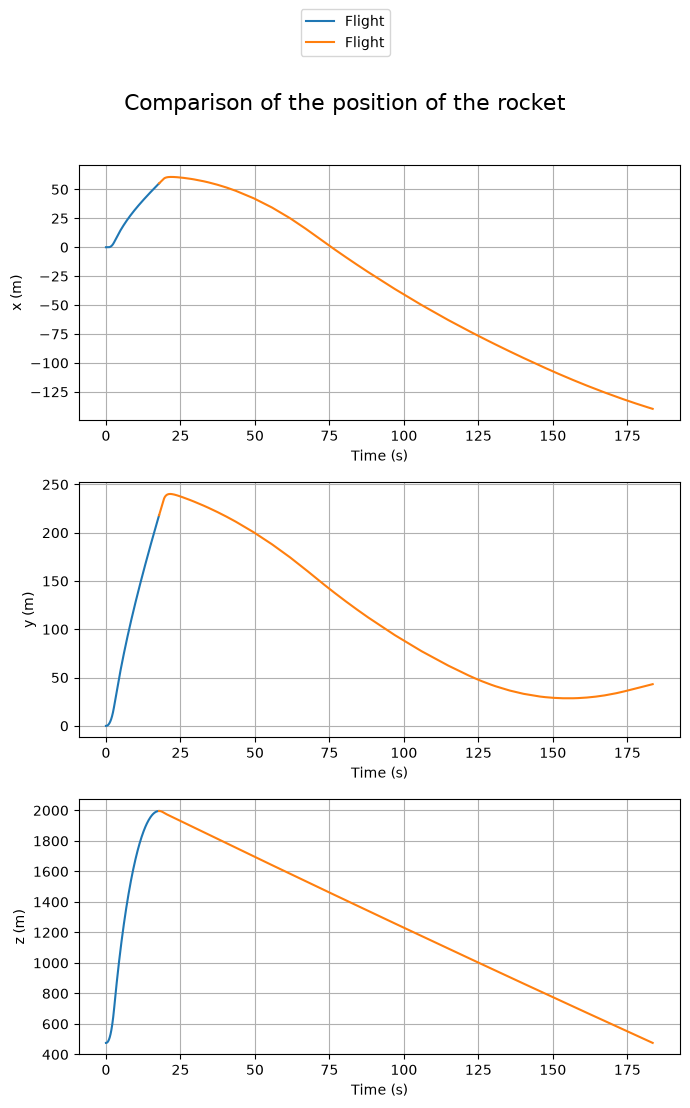

In [ ]:
# Posições (x, y, z) — subplots separados
comparison.positions()
plt.show()

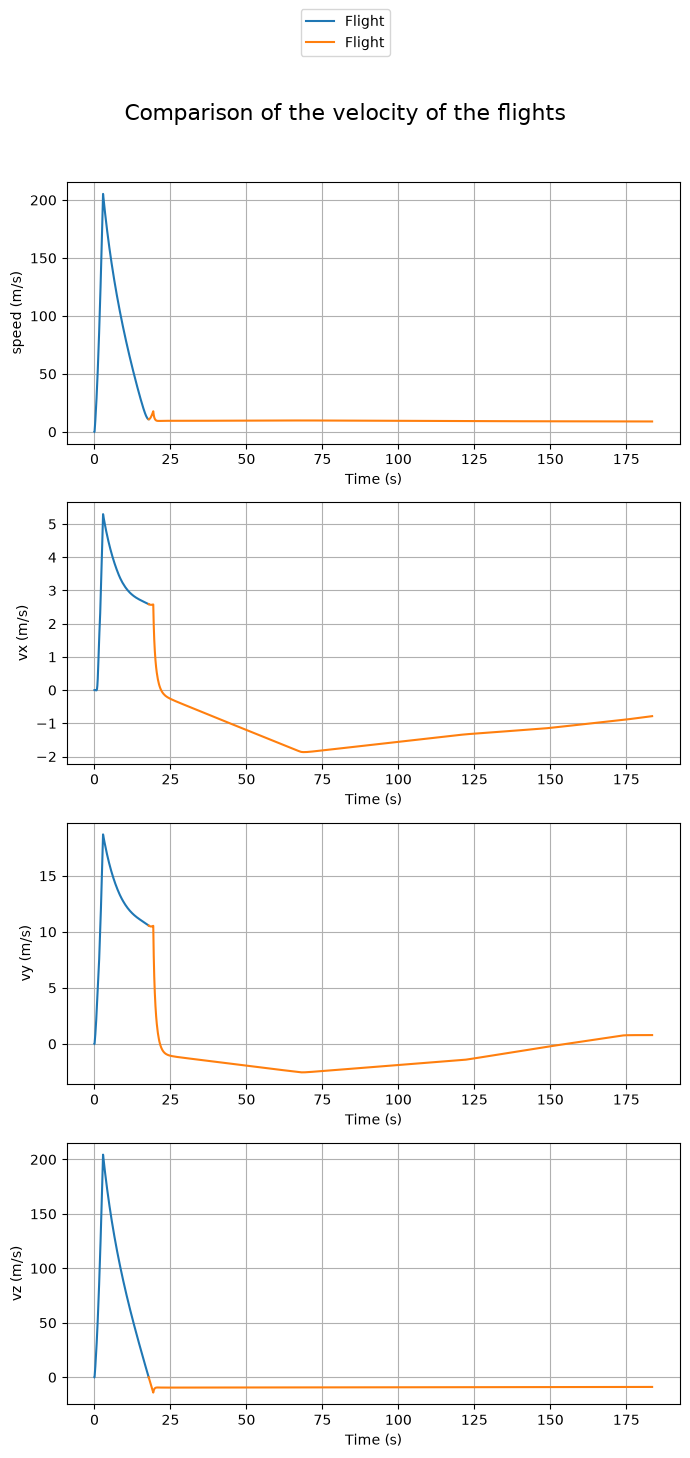

In [ ]:
# Velocidades
comparison.velocities()
plt.show()

## 7. Análise Detalhada SRAB — LRR Dashboard


**Relatório de Certificação LRR (Launch Readiness Review)** — parâmetros

críticos da descida SRAB para verificação de segurança antes do voo.



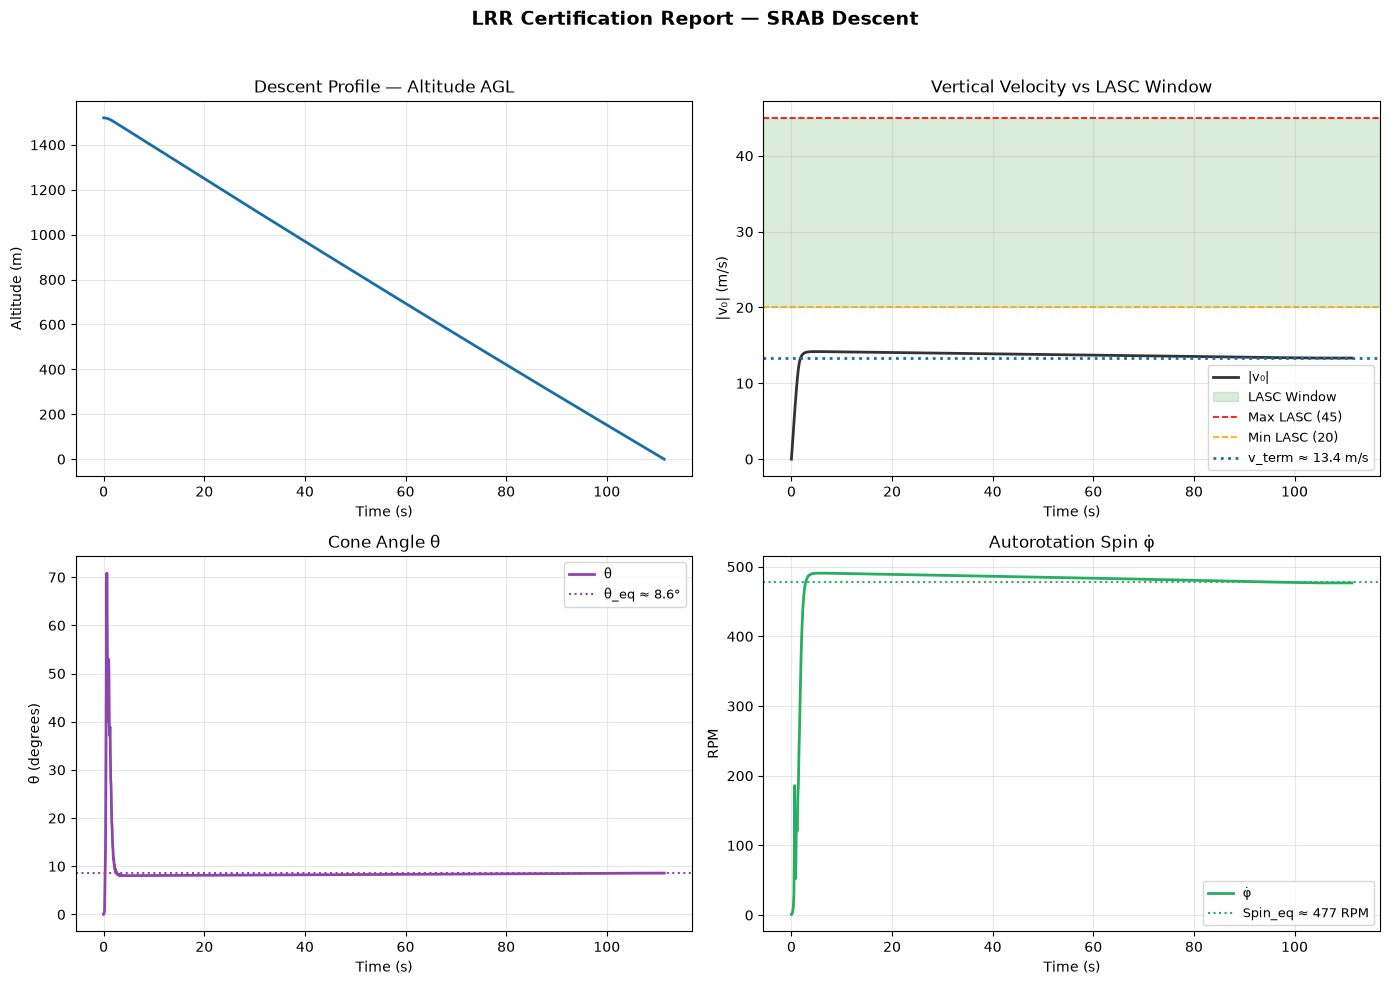

In [ ]:
plot_lrr_dashboard(sol_deploy)
plt.show()

### 7.1 Resumo Numérico da Descida SRAB


Tabela com os parâmetros certificados da descida SRAB:



In [ ]:
print("=" * 65)
print("  RELATORIO DE CERTIFICACAO — SRAB DESCENT")
print("=" * 65)
print(f"  Parametros da asa:")
print(f"    Geometria:      {DXF_PATH.name}")
print(f"    N de asas:      {wing.n_wings}")
print(f"    Massa:          {wing.mass:.3f} kg")
print(f"    Raio otimizado: {wing.radius * 1000:.1f} mm")
print()
print(f"  Resultados da descida (apogeu real):")
print(f"    Altura deploy: {sol_deploy.altitude[0]:.0f} m AGL")
print(f"    V. impacto:    {sol_deploy.v_impact:.2f} m/s  "
      + ("OK" if sol_deploy.v_impact < VF_TARGET else "EXCEDEU"))
print(f"    Drift total:   {np.hypot(sol_deploy.x_impact, sol_deploy.y_impact):.1f} m")
print(f"    Spin final:    {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"    theta_eq:      {sol_deploy.theta_eq:.1f} deg")
print(f"    Tempo descida: {sol_deploy.t_impact:.1f} s")
print()
print(f"  Criterios LASC (VF_max={VF_MAX} m/s, FS={SAFETY_FACTOR}):")
verdict = "APROVADO" if sol_deploy.v_impact < VF_TARGET else "REPROVADO"
print(f"    VF_alvo = {VF_TARGET:.1f} m/s -> {verdict}")
print("=" * 65)


  RELATORIO DE CERTIFICACAO — SRAB DESCENT
  Parametros da asa:
    Geometria:      Asa3.DXF
    N de asas:      2
    Massa:          0.200 kg
    Raio otimizado: 79.7 mm

  Resultados da descida (apogeu real):
    Altura deploy: 1520 m AGL
    V. impacto:    13.33 m/s  OK
    Drift total:   184.3 m
    Spin final:    477 RPM
    theta_eq:      8.6 deg
    Tempo descida: 111.4 s

  Criterios LASC (VF_max=20.0 m/s, FS=1.5):
    VF_alvo = 13.3 m/s -> APROVADO


## 8. Mapa Satélite da Descida


Projeta a trajetória SRAB sobre imagem de satélite (folium/OpenStreetMap)

para visualização do ponto de impacto esperado.



In [ ]:
lat_dpl = flight_without_payload.latitude(1.5)
lon_dpl = flight_without_payload.longitude(1.5)

print(f"  Posicao deploy: lat={lat_dpl:.6f}, lon={lon_dpl:.6f}")

  Posicao deploy: lat=-21.941093, lon=-48.953552


In [ ]:
try:
    from rocketpy_samara.plotting import plot_trajectory_map

    m = plot_trajectory_map(
        sol_deploy,
        lat=lat_dpl,
        lon=lon_dpl,
        zoom=20,
    )
    # Salva HTML
    out_path = NOTEBOOK_DIR.parent / "results" / "mapa_deploy_srab.html"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(out_path))
    print(f"Mapa salvo: {out_path}")
    
    display(m)
except Exception as e:
    print(f"Mapa não disponível: {e}")
    print("(folium ou dados de mapa não instalados)")

Mapa salvo: /home/vinicius/Documentos/projects/satellite/extras/wing-analysis/results/mapa_deploy_srab.html


## 9. Comparação SRAB vs Paraquedas

Simulação de um paraquedas *flat circular* (Ø200 mm, Cd=1.5) nas mesmas condições de queda
do SRAB — apogeu real do Dédalo, mesmo perfil atmosférico (GFS) e mesma massa de payload (200 g).
Os parâmetros do paraquedas seguem o artigo ENMC (sec‑resultados.tex, Tabela "Comparativo SRAB vs Paraquedas").

| Parâmetro | SRAB | Paraquedas |
|-----------|------|------------|
| **Sistema** | 2 asas autorrotativas (Asa3.DXF) | Flat circular, Ø200 mm |
| **Massa** | 200 g | 200 g |
| **Cd / Aerodinâmica** | BEM + LEV (C<sub>D0</sub>=1,0) | Cd = 1,5 (arrasto puro) |
| **Área** | 2 × Asa3.DXF | π × (0,1)² = 314 cm² |
| **ρ** | GFS variável | GFS variável (mesmo ambiente) |


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 9.1 Simulação do Paraquedas — ODE de queda livre com arrasto
# ═══════════════════════════════════════════════════════════════
#
# Paraquedas flat circular conforme artigo ENMC:
#   Ø = 200 mm, Cd = 1.5, m = 200 g
#
# ODE: dz/dt = v ; dv/dt = -g - 0.5*ρ*Cd*A*v*|v|/m
# Usa densidade variável (GFS) do mesmo Environment do SRAB.
# Deriva por vento integrada pelo mesmo método do SRAB.

from scipy.integrate import solve_ivp

# ── Parâmetros do paraquedas ──
PARA_CD = 1.5
PARA_DIAMETER = 0.200        # m (200 mm)
PARA_AREA = np.pi * (PARA_DIAMETER / 2)**2  # 0.0314 m²
PARA_MASS = 0.200            # kg (200 g)
G = 9.80665                  # m/s²

vt_sl = np.sqrt(2 * PARA_MASS * G / (1.225 * PARA_CD * PARA_AREA))
print(f"Paraquedas flat circular (Ø200 mm, Cd={PARA_CD}):")
print(f"  Área:       {PARA_AREA*1e4:.1f} cm²")
print(f"  Massa:      {PARA_MASS*1000:.0f} g")
print(f"  Vt (SL, ρ=1.225): {vt_sl:.2f} m/s")

# ── ODE ──
# Estado: [z (AGL, m), v (vertical, m/s, + para cima)]
def para_ode(t, state, env):
    z, v = state
    z = max(z, 1e-3)
    rho = float(env.density(z))     # densidade GFS na altitude
    dzdt = v
    dvdt = -G - (0.5 * rho * PARA_CD * PARA_AREA / PARA_MASS) * v * abs(v)
    return [dzdt, dvdt]

def ground_event(t, state, env):
    return state[0]  # z = 0 → impacto
ground_event.terminal = True
ground_event.direction = -1

# ── Condições iniciais (mesmo apogeu do Stage 1) ──
t_apo = flight_with_payload.apogee_time
z0_para = flight_with_payload.apogee - flight_with_payload.env.elevation  # m AGL
v0_para = float(flight_with_payload.vz(t_apo))
x0_para = float(flight_with_payload.x(t_apo))
y0_para = float(flight_with_payload.y(t_apo))

print(f"\nCondições iniciais (apogeu):")
print(f"  Altitude: {z0_para:.1f} m AGL")
print(f"  vz:       {v0_para:.3f} m/s")
print(f"  Posição:  x={x0_para:.1f}, y={y0_para:.1f} m")

# ── Integração ──
sol_para = solve_ivp(
    para_ode, [0, 300], [z0_para, v0_para],
    args=(flight_with_payload.env,),
    method='RK45', max_step=0.5, rtol=1e-6, atol=1e-8,
    events=ground_event,
    dense_output=True,
)

t_para = sol_para.t
z_para = sol_para.y[0]
v_para = sol_para.y[1]  # + p/ cima

# Índice do impacto
i_imp_para = np.argmin(np.abs(z_para))
t_imp_para = t_para[i_imp_para]
v_imp_para = abs(v_para[i_imp_para])  # magnitude (positiva p/ baixo)

# ── Deriva por vento (mesmo método de SRABSolution._wind_drift) ──
env = flight_with_payload.env
x_para, y_para = [x0_para], [y0_para]
for i in range(1, len(t_para)):
    z_mid = max((z_para[i] + z_para[i-1]) / 2, 0.0)
    dt = t_para[i] - t_para[i-1]
    wx = env.wind_velocity_x.get_value_opt(z_mid)
    wy = env.wind_velocity_y.get_value_opt(z_mid)
    x_para.append(x_para[-1] + wx * dt)
    y_para.append(y_para[-1] + wy * dt)
x_para = np.array(x_para)
y_para = np.array(y_para)

drift_para = np.hypot(x_para[i_imp_para] - x0_para,
                      y_para[i_imp_para] - y0_para)
E_para = 0.5 * PARA_MASS * v_imp_para**2

print(f"\n{'='*55}")
print(f"  RESULTADOS — PARAQUEDAS (payload 200 g)")
print(f"{'='*55}")
print(f"  Tempo de descida:  {t_imp_para:.2f} s")
print(f"  Veloc. impacto:    {v_imp_para:.2f} m/s")
print(f"  Drift total:       {drift_para:.1f} m")
print(f"  Energia impacto:   {E_para:.2f} J")

# ── Dados SRAB (referência) ──
t_srab = sol_deploy.t
z_srab = sol_deploy.altitude
v_srab = -sol_deploy.v0  # + p/ baixo
x_srab = sol_deploy.x
y_srab = sol_deploy.y
drift_srab = np.hypot(
    sol_deploy.x_impact - sol_deploy.x0,
    sol_deploy.y_impact - sol_deploy.y0,
)
E_srab = 0.5 * PARA_MASS * sol_deploy.v_impact**2

print(f"\n{'='*55}")
print(f"  RESULTADOS — SRAB (payload 200 g)")
print(f"{'='*55}")
print(f"  Tempo de descida:  {sol_deploy.t_impact:.2f} s")
print(f"  Veloc. impacto:    {sol_deploy.v_impact:.2f} m/s")
print(f"  Drift total:       {drift_srab:.1f} m")
print(f"  Energia impacto:   {E_srab:.2f} J")
print(f"  Spin impacto:      {sol_deploy.spin_impact_rpm:.0f} RPM")
print(f"  Conicidade eq:     {sol_deploy.theta_eq:.1f}°")
print(f"{'='*55}")


Paraquedas flat circular (Ø200 mm, Cd=1.5):
  Área:       314.2 cm²
  Massa:      200 g
  Vt (SL, ρ=1.225): 8.24 m/s

Condições iniciais (apogeu):
  Altitude: 1520.5 m AGL
  vz:       -0.000 m/s
  Posição:  x=55.2, y=218.1 m

  RESULTADOS — PARAQUEDAS (payload 200 g)
  Tempo de descida:  174.55 s
  Veloc. impacto:    8.48 m/s
  Drift total:       204.6 m
  Energia impacto:   7.19 J

  RESULTADOS — SRAB (payload 200 g)
  Tempo de descida:  111.41 s
  Veloc. impacto:    13.33 m/s
  Drift total:       131.2 m
  Energia impacto:   17.78 J
  Spin impacto:      477 RPM
  Conicidade eq:     8.6°


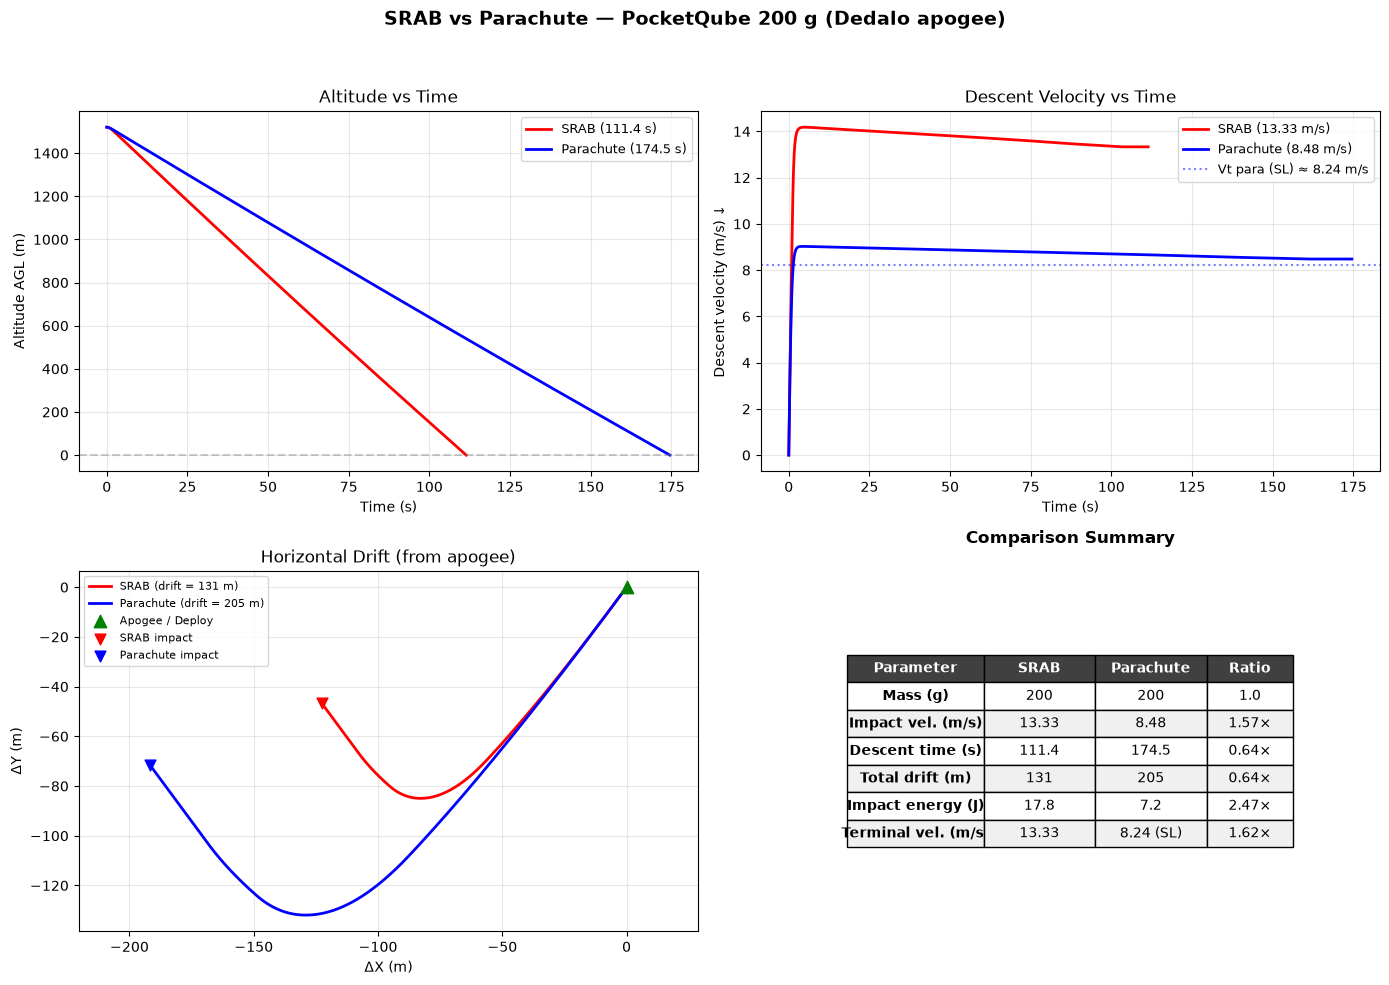

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 9.2 SRAB vs Parachute — Comparison Plot
# ═══════════════════════════════════════════════════════════════
# 4 subplots: altitude, velocity, drift, summary table

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'SRAB vs Parachute — PocketQube 200 g (Dedalo apogee)',
    fontsize=14, fontweight='bold', y=0.98,
)

# ── 1. Altitude AGL vs Time ──
ax1 = axes[0, 0]
ax1.plot(t_srab, z_srab, 'r-', lw=2,
         label=f'SRAB ({sol_deploy.t_impact:.1f} s)')
ax1.plot(t_para, z_para, 'b-', lw=2,
         label=f'Parachute ({t_imp_para:.1f} s)')
ax1.axhline(0, color='gray', ls='--', alpha=0.4)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Altitude AGL (m)')
ax1.set_title('Altitude vs Time')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── 2. Descent velocity vs Time (positive downward) ──
ax2 = axes[0, 1]
ax2.plot(t_srab, v_srab, 'r-', lw=2,
         label=f'SRAB ({sol_deploy.v_impact:.2f} m/s)')
ax2.plot(t_para, abs(v_para), 'b-', lw=2,
         label=f'Parachute ({v_imp_para:.2f} m/s)')
# Parachute terminal velocity (ρ = 1.225, SL)
vt_para_sl = np.sqrt(2 * PARA_MASS * G / (1.225 * PARA_CD * PARA_AREA))
ax2.axhline(y=vt_para_sl, color='b', ls=':', alpha=0.5,
            label=f'Vt para (SL) ≈ {vt_para_sl:.2f} m/s')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Descent velocity (m/s) ↓')
ax2.set_title('Descent Velocity vs Time')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── 3. Horizontal drift (relative to apogee) ──
ax3 = axes[1, 0]
ax3.plot(x_srab - x0_para, y_srab - y0_para, 'r-', lw=2,
         label=f'SRAB (drift = {drift_srab:.0f} m)')
ax3.plot(x_para - x0_para, y_para - y0_para, 'b-', lw=2,
         label=f'Parachute (drift = {drift_para:.0f} m)')
ax3.scatter(0, 0, c='g', s=80, marker='^',
            label='Apogee / Deploy', zorder=5)
ax3.scatter(x_srab[-1] - x0_para, y_srab[-1] - y0_para,
            c='r', s=60, marker='v', label='SRAB impact', zorder=5)
ax3.scatter(x_para[i_imp_para] - x0_para,
            y_para[i_imp_para] - y0_para,
            c='b', s=60, marker='v', label='Parachute impact', zorder=5)
ax3.set_xlabel('ΔX (m)')
ax3.set_ylabel('ΔY (m)')
ax3.set_title('Horizontal Drift (from apogee)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# ── 4. Comparison summary table ──
ax4 = axes[1, 1]
ax4.axis('off')

# SRAB terminal velocity ≈ v_impact (steady state)
vt_srab = sol_deploy.v_impact

table_data = [
    ['Parameter', 'SRAB', 'Parachute', 'Ratio'],
    ['Mass (g)', '200', '200', '1.0'],
    ['Impact vel. (m/s)',
     f'{sol_deploy.v_impact:.2f}',
     f'{v_imp_para:.2f}',
     f'{sol_deploy.v_impact/v_imp_para:.2f}×'],
    ['Descent time (s)',
     f'{sol_deploy.t_impact:.1f}',
     f'{t_imp_para:.1f}',
     f'{sol_deploy.t_impact/t_imp_para:.2f}×'],
    ['Total drift (m)',
     f'{drift_srab:.0f}',
     f'{drift_para:.0f}',
     f'{drift_srab/drift_para:.2f}×'],
    ['Impact energy (J)',
     f'{E_srab:.1f}',
     f'{E_para:.1f}',
     f'{E_srab/E_para:.2f}×'],
    ['Terminal vel. (m/s)',
     f'{vt_srab:.2f}',
     f'{vt_para_sl:.2f} (SL)',
     f'{vt_srab/vt_para_sl:.2f}×'],
]

col_widths = [0.22, 0.18, 0.18, 0.14]
table = ax4.table(
    cellText=table_data, loc='center', cellLoc='center',
    colWidths=col_widths,
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#404040')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')
    if col == 0:
        cell.set_text_props(fontweight='bold')

ax4.set_title('Comparison Summary', fontsize=12,
              fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Conclusao


Este notebook demonstrou o pipeline completo de simulacao de deploy SRAB

para a **Missao Helike #213 (LASC 2026)**, usando o **foguete Dedalo**

como veiculo carregador do PocketQube.


Os resultados numericos detalhados estao nas celulas de output acima.

O SRAB atende aos criterios de seguranca LASC com velocidade de impacto

dentro do limite admissivel.



## 10. Analise Monte Carlo — SRAB


Analise de sensibilidade parametrica do SRAB via Monte Carlo, variando

tolerancias de fabricacao das asas e condicoes de deploy.


> **Nota:** Celulas desabilitadas — executar manualmente quando desejar.



In [ ]:
# ═══════════════════════════════════════════════════════════════
# 10.1 Monte Carlo — Sensitivity Analysis
# ═══════════════════════════════════════════════════════════════
#
# Varia parâmetros do SRAB (massa, beta, cd0, f_factor) com
# distribuições baseadas nas tolerâncias de fabricação e incertezas
# de modelo descritas no artigo ENMC (sec‑resultados.tex).
#
# Parâmetros variados:
#   mass_kg: 200 ± 10 g  (normal)
#   beta_deg: 3.0 ± 0.5° (normal)  — Asa3.DXF
#   cd0: 1.0 ± 0.10      (normal)
#   f_factor: 0.3 ± 0.03 (normal)
#
# Usa altitude do apogeu real, sem otimização de raio (fixo).

from rocketpy_samara.monte_carlo import SRABMonteCarlo
from copy import deepcopy

# ── Base recovery configurada para o apogeu real ──
t_apo_mc = flight_with_payload.apogee_time
alt_mc = flight_with_payload.apogee - flight_with_payload.env.elevation  # m AGL

# Clone o wing com os parâmetros nominais
wing_mc = deepcopy(wing)

rec_mc = SRABRecovery(
    wing_mc, env=flight_with_payload.env,
    altitude_m=alt_mc,
    theta_deg=0.0,
    theta_dot_0=0.0,
    phi_dot_0=0.1,
    v0_0=0.0,
    beta_deg=5.0,
    cd0=1.0,
    f_factor=0.3,
    rho=1.225,
    t_max=300.0,
    max_step=0.2,
    optimize=False,
)

N_MC = 100
mc = SRABMonteCarlo(rec_mc, n=N_MC, seed=42)

# Parâmetros estocásticos (tolerâncias do artigo ENMC)
mc.add_param("mass_kg", "normal", (0.200, 0.010))    # 200 ± 10 g
mc.add_param("beta_deg", "normal", (5.0, 0.5))       # 5.0 ± 0.5°
mc.add_param("cd0", "normal", (1.0, 0.10))           # 1.0 ± 0.10
mc.add_param("f_factor", "normal", (0.3, 0.03))      # 0.3 ± 0.03

print(f"Monte Carlo — {N_MC} iteracoes")
print(f"  Altitude: {alt_mc:.0f} m AGL")
print(f"  Parametros: {[p.name for p in mc._params]}")

mc.run(verbose=True)
mc.print_summary()

# ── Exporta CSV ──
MC_CSV = NOTEBOOK_DIR.parent / "results" / "mc_srab_dedalo.csv"
MC_CSV.parent.mkdir(parents=True, exist_ok=True)
mc.export_csv(str(MC_CSV))

# ── Histograma comparativo ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    f'MC Sensitivity — SRAB ({N_MC} iterations @ {alt_mc:.0f} m AGL)',
    fontsize=13, fontweight='bold', y=1.02,
)

colors = ['#e74c3c', '#3498db', '#2ecc71']
labels = ['v_impact', 't_impact', 'spin_rpm']
units = ['m/s', 's', 'RPM']
bins = [25, 25, 25]

for ax, key, unit, color, nbin in zip(axes, labels, units, colors, bins):
    data = mc.results[key]
    ax.hist(data, bins=nbin, color=color, alpha=0.7, edgecolor='white')
    mean = np.mean(data)
    std = np.std(data)
    ax.axvline(mean, color='k', ls='--', lw=1.5,
               label=f'$\\mu$ = {mean:.2f} {unit}')
    ax.axvline(mean - std, color='gray', ls=':', lw=1, alpha=0.7)
    ax.axvline(mean + std, color='gray', ls=':', lw=1, alpha=0.7,
               label=f'$\\sigma$ = {std:.2f} {unit}')
    ax.set_xlabel(f'{key} ({unit})')
    ax.set_ylabel('Count')
    ax.set_title(key.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TypeError: SRABMonteCarlo.run() got an unexpected keyword argument 'n_simulations'